# Reproducible Data Workflow for Video Game Sales, Ratings, and Genre Trends

**Student:** Robert Mayfield  
**Project:** AI Programming Foundations - Udacity AI MBA Capstone  
**Dataset:** Video Game Sales, Ratings, and Genre Data

## 1. Project Overview

This project focuses on building a clean, reusable, and reproducible data workflow using Python, Pandas, NumPy, Matplotlib, and Seaborn. The `Video Game Sales and Ratings` dataset contains video game market information such as game titles, platforms, genres, publishers, sales figures, ratings, and review scores. The goal is to clean and explore the dataset, create meaningful visualizations, and summarize insights that help establish industry context for a future AI-assisted projects meant to assist game developers in building better and more efficient products.

### Core Question

What patterns in video game genre, platform, sales, and ratings data can inform the design focus of an AI assisted game development tool?

## 2. Setup

The following imports cover the full project: standard library utilities, data processing libraries, visualization libraries, and the reusable functions from `src/`.

In [9]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.inspection import inspect_dataframe
from src.cleaning import clean_column_names, handle_missing_values, clean_column_types
from src.eda import summarize_game_market

## 3. Data Ingestion

The dataset is stored as a zip archive at `data/raw/Video_Game_Sales_as_of_Jan_2017.csv.zip` and contains a single CSV file, `Video_Game_Sales_as_of_Jan_2017.csv` (kendallgillies, 2017). The data is loaded directly from the archive without extracting to disk, keeping the raw data directory clean and the workflow self contained.

In [10]:
ZIP_PATH = '../data/raw/Video_Game_Sales_as_of_Jan_2017.csv.zip'
CSV_NAME = 'Video_Game_Sales_as_of_Jan_2017.csv'

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    with z.open(CSV_NAME) as f:
        df = pd.read_csv(f)

df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN


## 4. Initial Dataset Inspection

Before cleaning or analysis, we run a full inspection of the dataset to understand its structure, identify missing values, spot duplicates, and get a sense of the distributions across numeric and categorical columns. The `inspect_dataframe` function from `src/inspection.py` packages these steps into a single reusable call.

In [11]:
inspect_dataframe(df)

SHAPE AND STRUCTURE
------------------------------------------------------------
Rows:    17,416
Columns: 15

COLUMN NAMES AND DATA TYPES
------------------------------------------------------------
Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score         float64
User_Count         float64
Rating              object

MEMORY USAGE
------------------------------------------------------------
Total: 6.69 MB

MISSING VALUES
------------------------------------------------------------
                 Null Count  Null %
User_Score             9618   55.23
User_Count             9618   55.23
Critic_Score           9080   52.14
Critic_Count           9080   52.14
Rating                 7164   41.13
Year_of_Relea

### Inspection Notes

**Shape and Structure:** The dataset contains 17,416 rows and 15 columns. Columns cover game titles, platforms, release years, genres, publishers, four regional sales figures, global sales, critic and user review scores, and ESRB ratings. Total memory footprint is 6.69 MB.

**Data Types:** All sales and score columns load as float64, including `User_Score`. `Year_of_Release` also loads as float64 rather than integer due to missing values in that column. It will be converted to integer after those rows are dropped during cleaning.

**Missing Values:** The dataset has substantial missingness concentrated in review related columns. `User_Score` and `User_Count` are each missing for 9,618 records (55.23%), and `Critic_Score` and `Critic_Count` are each missing for 9,080 records (52.14%). `Rating` is missing for 7,164 records (41.13%). This pattern is consistent with the history of game journalism: older and lower profile titles were frequently not reviewed by critics or users. `Year_of_Release` is missing for just 8 records (0.05%), and `Publisher` for 1 record (0.01%). `Name` and `Genre` have no missing values. The review column gaps are significant enough that any analysis involving scores will be working with roughly half the dataset.

**Duplicate Rows:** No duplicate rows are present.

**Numeric Distributions:** Sales figures are heavily right skewed across all regions. The median global sales figure is 0.16 million units while the maximum is 82.54 million, and the 75th percentile sits at just 0.45 million. The vast majority of titles sell modestly, with a small number of blockbusters driving the upper range. `Critic_Score` ranges from 13 to 98 with a mean of 69, suggesting most reviewed titles cluster in the average to good range. `User_Count` has an extreme distribution with a mean of 163 but a maximum of 10,766 and a large standard deviation, indicating that a handful of titles attract enormous user review volume while most receive very few. Release years span 1976 to 2017 with a mean of 2006.6, reflecting that the bulk of the dataset covers the mid-2000s peak of the disc-based console era.

**Categorical Summaries:** There are 31 unique platforms in the dataset, with DS being the most represented at 2,251 titles. Genre has only 12 unique values, with Action being the most common at 3,503 titles. Publisher has 627 unique values, with Electronic Arts appearing most frequently at 1,380 titles. Rating has 8 unique values with E (Everyone) being the most common at 4,120 titles, followed by other ESRB categories.

**Sample Data:** The first rows confirm the dataset is sorted by global sales descending, with Nintendo titles dominating the top. Platform `G` represents the Game Boy, as confirmed by Pokemon Red/Pokemon Blue appearing as the fourth highest selling title. The last rows show titles at the minimum observed sales threshold of 0.01 million, and several are missing review data entirely, consistent with the missing value patterns described above.

### Extended Missingness Analysis

The high missingness in review columns warrants a closer look before making cleaning decisions. The following cells examine whether gaps are random or concentrated in specific years, platforms, or genres, and whether the review columns tend to go missing together.

#### Critic Score Missingness by Release Year

In [12]:
year_df = df.dropna(subset=['Year_of_Release']).copy()
year_df['Year_of_Release'] = year_df['Year_of_Release'].astype(int)

missing_by_year = (
    year_df.groupby('Year_of_Release')['Critic_Score']
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
    .reset_index()
    .rename(columns={'Critic_Score': 'Critic_Score_Missing_%'})
)

print(missing_by_year.to_string(index=False))

 Year_of_Release  Critic_Score_Missing_%
            1976                   100.0
            1977                   100.0
            1978                   100.0
            1979                   100.0
            1980                   100.0
            1981                   100.0
            1982                   100.0
            1983                   100.0
            1984                   100.0
            1985                    92.9
            1986                   100.0
            1987                   100.0
            1988                    93.3
            1989                   100.0
            1990                   100.0
            1991                   100.0
            1992                    97.7
            1993                   100.0
            1994                    99.2
            1995                   100.0
            1996                    97.0
            1997                    93.5
            1998                    92.7
            1999

#### Critic Score Missingness by Platform

In [13]:
missing_by_platform = (
    df.groupby('Platform')['Critic_Score']
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Critic_Score': 'Critic_Score_Missing_%'})
)

print(missing_by_platform.to_string(index=False))

Platform  Critic_Score_Missing_%
    2600                   100.0
     3DO                   100.0
       G                   100.0
     NES                   100.0
     N64                   100.0
      GG                   100.0
     GEN                   100.0
    PCFX                   100.0
      NG                   100.0
     SCD                   100.0
      WS                   100.0
    SNES                   100.0
    TG16                   100.0
     SAT                   100.0
      PS                    83.1
     PSV                    75.0
      DC                    73.1
     3DS                    68.7
      DS                    67.7
     PSP                    63.7
     Wii                    56.7
     GBA                    46.9
     PS2                    40.8
    WiiU                    40.5
     PS3                    39.3
     PS4                    36.1
    XOne                    31.8
      PC                    29.7
    X360                    28.5
      GC  

#### Critic Score Missingness by Genre

In [14]:
missing_by_genre = (
    df.dropna(subset=['Genre']).groupby('Genre')['Critic_Score']
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Critic_Score': 'Critic_Score_Missing_%'})
)

print(missing_by_genre.to_string(index=False))

       Genre  Critic_Score_Missing_%
   Adventure                    76.9
        Misc                    70.9
      Puzzle                    62.3
  Simulation                    60.3
    Strategy                    55.9
    Fighting                    51.6
Role-Playing                    50.9
      Sports                    49.6
      Action                    44.8
    Platform                    44.3
      Racing                    41.0
     Shooter                    28.6


#### Records Missing Year of Release

In [15]:
missing_year = df[df['Year_of_Release'].isnull()]
print(f"Records missing Year_of_Release: {len(missing_year)}\n")
print(missing_year[['Name', 'Platform', 'Genre', 'Publisher', 'Global_Sales']].to_string())

Records missing Year_of_Release: 8

                                             Name Platform       Genre                 Publisher  Global_Sales
12795                Mobile Ops: The One Year War     X360  Simulation        Namco Bandai Games          0.06
14210                                Housekeeping       DS      Action                   Unknown          0.04
14532            Fullmetal Alchemist: Brotherhood      PSP      Action                   Unknown          0.03
15162                 Wii de Asobu: Metroid Prime      Wii     Shooter                  Nintendo          0.02
15784  Writing and Speaking Beautiful Japanese DS       DS        Misc                   Unknown          0.02
16176                Ferrari: The Race Experience      Wii      Racing  System 3 Arcade Software          0.02
16953                                     Sumioni      PSV      Action                       NaN          0.01
17271                                Free Running      PSP      Sports      

#### Review Column Co-occurrence of Missingness

In [16]:
review_cols = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Rating']

# How many review columns are missing per record
missing_per_record = df[review_cols].isnull().sum(axis=1).value_counts().sort_index()
print("Number of review columns missing per record:")
for n_missing, count in missing_per_record.items():
    pct = count / len(df) * 100
    print(f"  {n_missing} columns missing: {count:,} records ({pct:.1f}%)")

print()

# Do Critic_Score and User_Score tend to go missing together?
both_missing = df[df['Critic_Score'].isnull() & df['User_Score'].isnull()].shape[0]
critic_only  = df[df['Critic_Score'].isnull() & df['User_Score'].notna()].shape[0]
user_only    = df[df['Critic_Score'].notna()  & df['User_Score'].isnull()].shape[0]

print("Critic_Score and User_Score co-occurrence:")
print(f"  Both missing:          {both_missing:,}")
print(f"  Only Critic_Score missing: {critic_only:,}")
print(f"  Only User_Score missing:   {user_only:,}")

Number of review columns missing per record:
  0 columns missing: 7,112 records (40.8%)
  1 columns missing: 79 records (0.5%)
  2 columns missing: 1,718 records (9.9%)
  3 columns missing: 34 records (0.2%)
  4 columns missing: 1,422 records (8.2%)
  5 columns missing: 7,051 records (40.5%)

Critic_Score and User_Score co-occurrence:
  Both missing:          8,473
  Only Critic_Score missing: 607
  Only User_Score missing:   1,145


### Extended Missingness Findings and Cleaning Decisions

**Missingness by release year** reveals a sharp and systematic pattern. Titles released before 2000 are almost entirely missing critic scores, with most years in the 1980s and 1990s at or near 100% missingness. The coverage improves dramatically around 2000 to 2001, dropping to roughly 32% to 59% missing, which aligns with the rise of dedicated games journalism and online review aggregation. Missingness then climbs again in the later years of the dataset, reflecting incomplete data collection rather than a lack of reviews. The missingness is not random. It is a direct function of when structured review data became consistently available.

**Missingness by platform** reinforces this conclusion. Every retro and legacy platform (NES, SNES, N64, G, GEN, 2600, and others) shows 100% missingness. Older platforms that straddle the pre and post review era such as PS (83.1%) and DC (73.1%) show high but not complete gaps. Portable platforms (PSV 75.0%, 3DS 68.7%, DS 67.7%, PSP 63.7%) show elevated missingness even in the modern era, suggesting that handheld titles received less consistent critical coverage than their console counterparts. The most modern, high profile platforms (X 12.0%, GC 19.4%, PC 29.7%, X360 28.5%) have the lowest missingness.

**Missingness by genre** shows a wider spread than the year and platform patterns. Adventure (76.9%) and Misc (70.9%) genres are most affected, while Shooter (28.6%) has the lowest missingness. This likely reflects that shooter and action titles attracted more consistent critical attention while niche genres such as adventure and simulation received less formal review coverage.

**Co-occurrence of missingness** is the most important finding for the cleaning decision. The data is strongly bimodal: 40.8% of records have none of the five review columns missing, and 40.5% have all five missing. Only 18.7% of records fall somewhere in between. This means the dataset contains two largely distinct populations: well reviewed games with complete data and unreviewed games with no review data at all. Critic_Score and User_Score are often missing together: 8,473 records are missing both. However, 607 records are missing only Critic_Score and 1,145 are missing only User_Score, reflecting that some titles accumulated user scores on Metacritic without receiving a formal critic aggregate.

**Records missing Year_of_Release** include recognizable titles such as Mobile Ops: The One Year War and Wii de Asobu: Metroid Prime, indicating these are real games with a data collection gap rather than erroneous entries. Since year is required for any time based analysis and only 8 records are affected (0.05%), dropping these rows is a low impact decision.

---

**Cleaning Decisions**

Based on this analysis, the following decisions will guide the cleaning functions:

| Column(s) | Decision | Reasoning |
|---|---|---|
| Duplicate rows | Drop | No duplicates present in this dataset |
| `Name`, `Genre` (0 missing) | N/A | No rows need to be dropped for these fields |
| `Publisher` (1 missing) | Drop rows | Small count, publisher needed for meaningful grouping |
| `Year_of_Release` (8 missing) | Drop rows | Required for time analysis; very small percentage |
| `Critic_Score`, `Critic_Count`, `User_Score`, `User_Count`, `Rating` | Keep NaN | Missingness is systematic and era driven, not a data error. Dropping would eliminate nearly all pre-2000 titles and bias the dataset toward the modern era. Score based analyses will drop nulls at the point of use. |

## 5. Data Cleaning Functions

Three cleaning functions are defined in `src/cleaning.py` and applied in sequence below. Each function returns a copy of the DataFrame, preserving the raw data unchanged. The cleaning decisions applied here are documented and justified in the extended missingness analysis in Section 4.

- `clean_column_names` standardizes all column names to lowercase.
- `handle_missing_values` drops duplicate rows and rows missing values in essential columns.
- `clean_column_types` converts `year_of_release` from float64 to int64. This step runs last because the conversion requires all rows with missing year values to already be dropped.

In [17]:
rows_before = len(df)

df_clean = clean_column_names(df)
df_clean = handle_missing_values(df_clean)
df_clean = clean_column_types(df_clean)

rows_after = len(df_clean)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(f"Rows removed:         {rows_before - rows_after:,}")
print()
print(f"Columns: {list(df_clean.columns)}")
print(f"year_of_release dtype: {df_clean['year_of_release'].dtype}")

Rows before cleaning: 17,416
Rows after cleaning:  17,408
Rows removed:         8

Columns: ['name', 'platform', 'year_of_release', 'genre', 'publisher', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales', 'critic_score', 'critic_count', 'user_score', 'user_count', 'rating']
user_score dtype: float64
year_of_release dtype: int64


In [18]:
df_clean.head()

,name,platform,year_of_release,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,critic_score,critic_count,user_score,user_count,rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN


#### Cleaning Verification

In [19]:
checks = {
    "No duplicate rows":                df_clean.duplicated().sum() == 0,
    "No nulls in name":                 df_clean['name'].isnull().sum() == 0,
    "No nulls in genre":                df_clean['genre'].isnull().sum() == 0,
    "No nulls in publisher":            df_clean['publisher'].isnull().sum() == 0,
    "No nulls in year_of_release":      df_clean['year_of_release'].isnull().sum() == 0,
    "year_of_release is int64":         df_clean['year_of_release'].dtype == 'int64',
    "user_score values in range (0-10)": df_clean['user_score'].dropna().between(0, 10).all(),
    "All column names are lowercase":   all(c == c.lower() for c in df_clean.columns),
}

all_passed = True
for check, result in checks.items():
    status = "PASS" if result else "FAIL"
    if not result:
        all_passed = False
    print(f"  [{status}] {check}")

print()
print("All checks passed." if all_passed else "One or more checks failed.")

  [PASS] No duplicate rows
  [PASS] No nulls in name
  [PASS] No nulls in genre
  [PASS] No nulls in publisher
  [PASS] No nulls in year_of_release
  [PASS] user_score is float64
  [PASS] year_of_release is int64
  [PASS] No 'tbd' values in user_score
  [PASS] All column names are lowercase

All checks passed.


#### Save Cleaned Dataset

In [20]:
PROCESSED_PATH = '../data/processed/video_games_clean.csv'

df_clean.to_csv(PROCESSED_PATH, index=False)

print(f"Cleaned dataset saved to {PROCESSED_PATH}")
print(f"Shape: {df_clean.shape}")

Cleaned dataset saved to ../data/processed/video_games_clean.csv
Shape: (17408, 15)


### Cleaning Notes

**Rows removed:** The pipeline removed 8 rows total, reducing the dataset from 17,416 to 17,408. The raw dataset contained no duplicate rows. The 8 rows removed were missing values in one or more essential fields: year_of_release (8 records) and publisher (1 record), with one row satisfying both conditions.

**Column names:** All 15 column names are now lowercase, making them consistent and easier to reference throughout the rest of the notebook.

**user_score:** The column was already float64 on load and remains float64 after cleaning. The coercion step confirms the type and converts any unexpected non-numeric entries to NaN, though none were present in this dataset.

**year_of_release:** Now int64. The conversion is safe because all rows with a missing year were dropped before the cast, eliminating the fractional representation that float requires for nullable integers.

**Review columns retained:** `critic_score`, `critic_count`, `user_score`, `user_count`, and `rating` retain their NaN values. As established in the missingness analysis, these gaps are systematic and era driven. Analyses that require score data will filter to non-null rows at the point of use rather than discarding this data globally.

## 6. Exploratory Analysis Function

The exploratory analysis is organized around seven questions that connect directly to the core question: what patterns in genre, platform, sales, and ratings data can inform the design focus of an AI-assisted game development tool?

The `summarize_game_market` function in `src/eda.py` handles grouped aggregations that are reusable across future projects. Each question includes a tabular summary, a supporting chart, and an interpretation of the findings.

In [21]:
summaries = summarize_game_market(df_clean)

#### Q1: Which genres are most represented in the dataset?

In [22]:
print(summaries['genre_counts'].to_string())

              game_count  total_global_sales  mean_global_sales
genre                                                          
Action              3500             1761.89               0.50
Sports              2407             1340.99               0.56
Misc                1812              808.78               0.45
Role-Playing        1545              949.31               0.61
Adventure           1478              241.55               0.16
Shooter             1348             1067.28               0.79
Racing              1281              731.65               0.57
Simulation           924              392.78               0.43
Platform             900              831.74               0.92
Fighting             864              449.17               0.52
Strategy             734              175.72               0.24
Puzzle               615              243.76               0.40


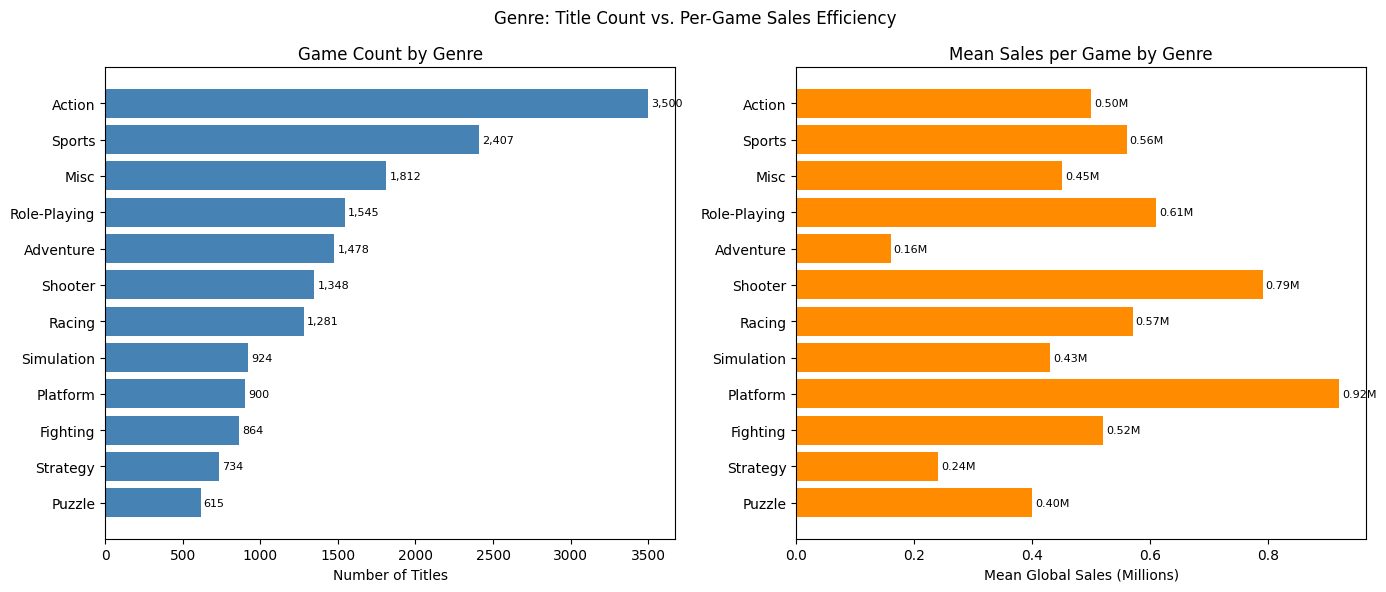

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

genre_data = summaries['genre_counts'].reset_index().sort_values('game_count')

axes[0].barh(genre_data['genre'], genre_data['game_count'], color='steelblue')
axes[0].set_xlabel('Number of Titles')
axes[0].set_title('Game Count by Genre')
for i, val in enumerate(genre_data['game_count']):
    axes[0].text(val + 20, i, f'{val:,}', va='center', fontsize=8)

axes[1].barh(genre_data['genre'], genre_data['mean_global_sales'], color='darkorange')
axes[1].set_xlabel('Mean Global Sales (Millions)')
axes[1].set_title('Mean Sales per Game by Genre')
for i, val in enumerate(genre_data['mean_global_sales']):
    axes[1].text(val + 0.005, i, f'{val:.2f}M', va='center', fontsize=8)

plt.suptitle('Genre: Title Count vs. Per-Game Sales Efficiency', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** Action is the dominant genre by title count at 3,500 games, nearly 45% more than the second largest genre, Sports at 2,407. Title count alone does not predict commercial efficiency. Platform titles average 0.92M in global sales each, the highest of any genre, while Action averages only 0.50M. Adventure has the lowest average at 0.16M despite 1,478 titles. These patterns show the market rewards genre selection differently from sheer volume, and the Platform genre's high revenue per release is a useful benchmark when evaluating design focus for a new title.

#### Q2: Which platforms are most represented in the dataset?

In [24]:
print(summaries['platform_counts'].to_string())

          game_count  total_global_sales  mean_global_sales
platform                                                   
DS              2249              808.82               0.36
PS2             2206             1256.09               0.57
PS3             1362              943.29               0.69
Wii             1357              910.14               0.67
PSP             1302              295.67               0.23
X360            1297              975.43               0.75
PS              1200              730.71               0.61
PC              1128              264.95               0.23
GBA              844              318.72               0.38
X                833              258.35               0.31
GC               563              199.43               0.35
3DS              553              270.94               0.49
PSV              502               57.02               0.11
PS4              424              340.79               0.80
N64              319              218.88

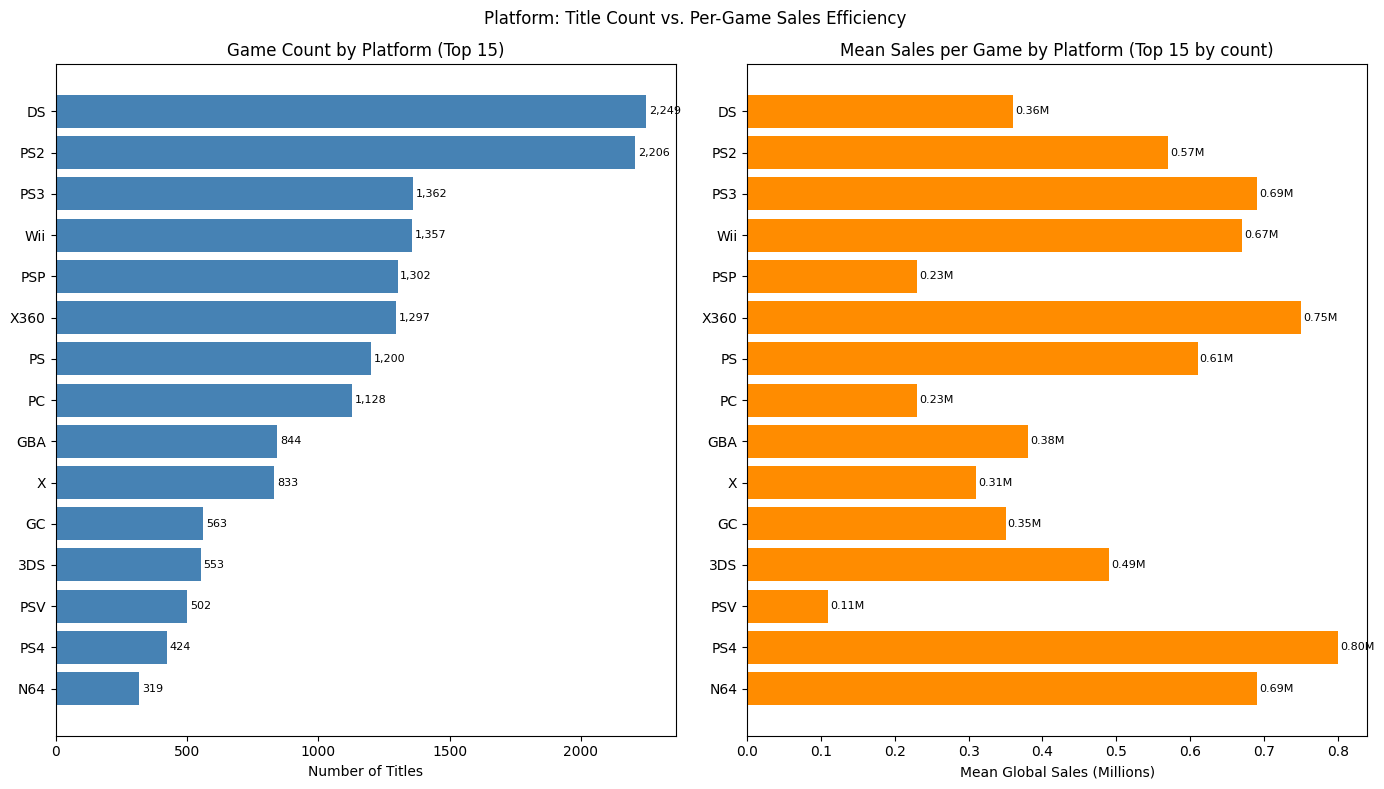

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

platform_data = summaries['platform_counts'].reset_index().head(15).sort_values('game_count')

axes[0].barh(platform_data['platform'], platform_data['game_count'], color='steelblue')
axes[0].set_xlabel('Number of Titles')
axes[0].set_title('Game Count by Platform (Top 15)')
for i, val in enumerate(platform_data['game_count']):
    axes[0].text(val + 10, i, f'{val:,}', va='center', fontsize=8)

axes[1].barh(platform_data['platform'], platform_data['mean_global_sales'], color='darkorange')
axes[1].set_xlabel('Mean Global Sales (Millions)')
axes[1].set_title('Mean Sales per Game by Platform (Top 15 by count)')
for i, val in enumerate(platform_data['mean_global_sales']):
    axes[1].text(val + 0.003, i, f'{val:.2f}M', va='center', fontsize=8)

plt.suptitle('Platform: Title Count vs. Per-Game Sales Efficiency', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** DS and PS2 lead in game count at 2,249 and 2,206 titles respectively, reflecting their long commercial lifespans and broad support from third party developers. NES (2.56M mean sales) and G (2.61M mean sales) show the highest averages per game despite small catalog sizes, which is a survivorship artifact: only commercially significant early era titles appear in this dataset. Platform G represents the Game Boy, confirmed by Nintendo flagship titles at the top of the sales rankings. Among modern platforms, PS4 (0.80M) and X360 (0.75M) show the strongest revenue per game. PSV stands out as an outlier with 502 titles but only 0.11M in mean sales, indicating the Vita attracted many releases that sold poorly in Western markets.

#### Q3: Which genres and platforms account for the most total global sales?

In [26]:
print("Global sales by genre (sorted by total):")
print(summaries['genre_counts'].sort_values('total_global_sales', ascending=False).to_string())
print()
print("Global sales by platform (sorted by total):")
print(summaries['platform_counts'].sort_values('total_global_sales', ascending=False).to_string())

Global sales by genre (sorted by total):
              game_count  total_global_sales  mean_global_sales
genre                                                          
Action              3500             1761.89               0.50
Sports              2407             1340.99               0.56
Shooter             1348             1067.28               0.79
Role-Playing        1545              949.31               0.61
Platform             900              831.74               0.92
Misc                1812              808.78               0.45
Racing              1281              731.65               0.57
Fighting             864              449.17               0.52
Simulation           924              392.78               0.43
Puzzle               615              243.76               0.40
Adventure           1478              241.55               0.16
Strategy             734              175.72               0.24

Global sales by platform (sorted by total):
          game_cou

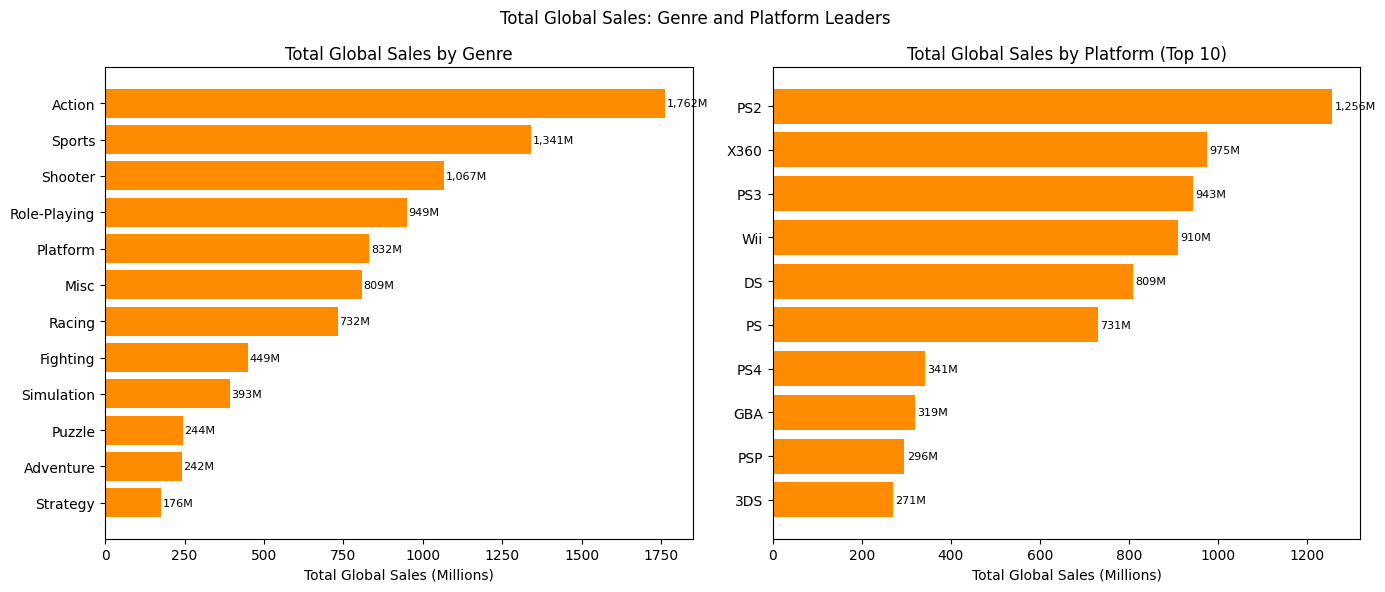

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

genre_sales = summaries['genre_counts'].sort_values('total_global_sales').reset_index()
axes[0].barh(genre_sales['genre'], genre_sales['total_global_sales'], color='darkorange')
axes[0].set_xlabel('Total Global Sales (Millions)')
axes[0].set_title('Total Global Sales by Genre')
for i, val in enumerate(genre_sales['total_global_sales']):
    axes[0].text(val + 5, i, f'{val:,.0f}M', va='center', fontsize=8)

platform_sales = (
    summaries['platform_counts']
    .sort_values('total_global_sales', ascending=False)
    .head(10)
    .sort_values('total_global_sales')
    .reset_index()
)
axes[1].barh(platform_sales['platform'], platform_sales['total_global_sales'], color='darkorange')
axes[1].set_xlabel('Total Global Sales (Millions)')
axes[1].set_title('Total Global Sales by Platform (Top 10)')
for i, val in enumerate(platform_sales['total_global_sales']):
    axes[1].text(val + 5, i, f'{val:,.0f}M', va='center', fontsize=8)

plt.suptitle('Total Global Sales: Genre and Platform Leaders', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** Action leads total global sales (1,761.89M) primarily due to its large title count rather than exceptional revenue per game. Shooter and Platform generate fewer titles but stronger sales per game (0.79M and 0.92M), making them more commercially efficient genres. Adventure generates the lowest average at 0.16M across 1,478 titles, indicating the genre is dominated by small commercial releases. Among platforms, PS2 volume drives the highest total sales (1,256.09M), while PS4 and X360 show that a smaller catalog can still generate substantial aggregate revenue through stronger average sales per title.

#### Q4: How have genre and platform patterns changed over time?

In [28]:
releases_by_year = (
    df_clean.groupby('year_of_release')['name']
    .count()
    .reset_index()
    .rename(columns={'name': 'game_count'})
)

print("Game releases by year:")
print(releases_by_year.to_string(index=False))
print()

top_genres = summaries['genre_counts'].head(5).index.tolist()
genre_by_year = (
    df_clean[df_clean['genre'].isin(top_genres)]
    .groupby(['year_of_release', 'genre'])['name']
    .count()
    .unstack(fill_value=0)
)

print("Release counts for top 5 genres by year:")
print(genre_by_year.to_string())

Game releases by year:
 year_of_release  game_count
            1976           1
            1977           3
            1978           4
            1979           1
            1980          14
            1981          46
            1982          37
            1983          18
            1984          14
            1985          14
            1986          21
            1987          16
            1988          15
            1989          17
            1990          16
            1991          41
            1992          44
            1993          60
            1994         121
            1995         219
            1996         263
            1997         294
            1998         382
            1999         343
            2000         354
            2001         491
            2002         869
            2003         801
            2004         779
            2005         968
            2006        1067
            2007        1262
            2008    

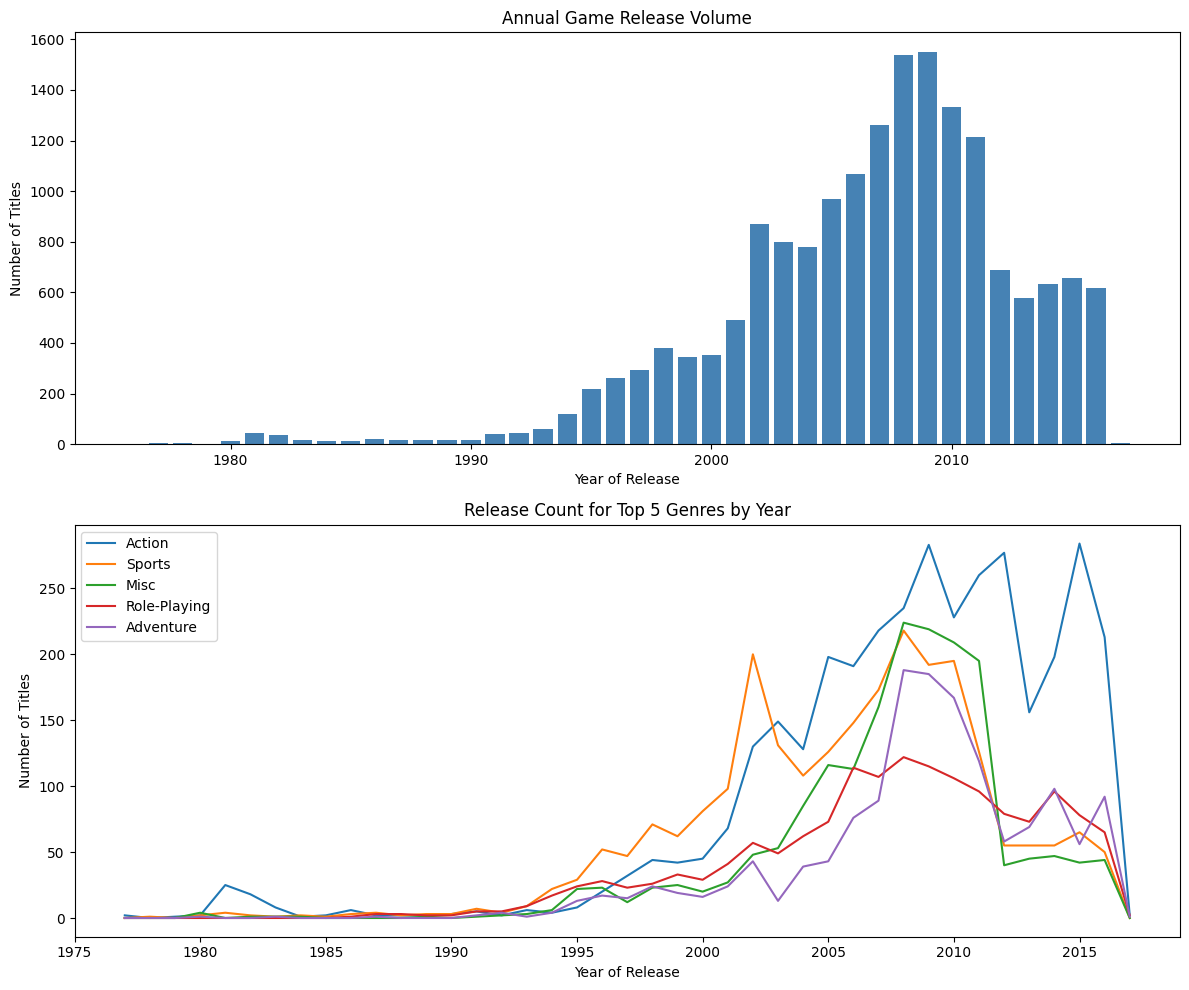

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

releases_by_year = df_clean.groupby('year_of_release')['name'].count().reset_index()
releases_by_year.columns = ['year_of_release', 'game_count']
axes[0].bar(releases_by_year['year_of_release'], releases_by_year['game_count'], color='steelblue', width=0.8)
axes[0].set_xlabel('Year of Release')
axes[0].set_ylabel('Number of Titles')
axes[0].set_title('Annual Game Release Volume')

top_genres = summaries['genre_counts'].head(5).index.tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
genre_year = (
    df_clean[df_clean['genre'].isin(top_genres)]
    .groupby(['year_of_release', 'genre'])['name']
    .count()
    .unstack(fill_value=0)
)
for genre, color in zip(top_genres, colors):
    axes[1].plot(genre_year.index, genre_year[genre], label=genre, color=color, linewidth=1.5)
axes[1].set_xlabel('Year of Release')
axes[1].set_ylabel('Number of Titles')
axes[1].set_title('Release Count for Top 5 Genres by Year')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:** Release volume grew from single digits in 1980 to a peak of 1,550 titles in 2009, then fell sharply after 2011. This reflects the industry shift toward releasing fewer titles with higher budgets and the rise of digital distribution, which is largely absent from this dataset. Action overtook Sports as the dominant genre around 2005 and remained at the top thereafter. The Sports surge in the early 2000s reflects annual franchise publishing cycles by EA Sports and 2K that contracted after 2011. The Misc genre spike from 2007 to 2011 corresponds to the Wii casual gaming era. Release counts drop to nearly zero after 2016 due to incomplete data collection rather than an actual market contraction.

#### Q5: How are global sales distributed, and are they concentrated among a small number of hit games?

In [30]:
sales = df_clean['global_sales']

print("Global sales distribution (millions of units):")
print(f"  Mean:   {sales.mean():.3f}")
print(f"  Median: {sales.median():.3f}")
print(f"  Std:    {sales.std():.3f}")
print(f"  Min:    {sales.min():.3f}")
print(f"  Max:    {sales.max():.3f}")
print()

bins   = [0, 0.1, 1.0, 10.0, float('inf')]
labels = ['Low (<0.1M)', 'Moderate (0.1-1M)', 'High (1-10M)', 'Blockbuster (>10M)']
df_clean['sales_tier'] = pd.cut(sales, bins=bins, labels=labels)

tier_counts = df_clean['sales_tier'].value_counts().reindex(labels)
tier_pct    = (tier_counts / len(df_clean) * 100).round(1)

print("Sales tier breakdown:")
for tier, count, pct in zip(labels, tier_counts, tier_pct):
    print(f"  {tier}: {count:,} games ({pct}%)")

print()
total_sales  = sales.sum()
top10_sales  = sales.nlargest(10).sum()
top100_sales = sales.nlargest(100).sum()
print(f"Top 10 games account for  {top10_sales / total_sales * 100:.1f}% of total global sales")
print(f"Top 100 games account for {top100_sales / total_sales * 100:.1f}% of total global sales")

Global sales distribution (millions of units):
  Mean:   0.517
  Median: 0.160
  Std:    1.526
  Min:    0.010
  Max:    82.540

Sales tier breakdown:
  Low (<0.1M): 6,937 games (39.8%)
  Moderate (0.1-1M): 8,406 games (48.3%)
  High (1-10M): 2,001 games (11.5%)
  Blockbuster (>10M): 64 games (0.4%)

Top 10 games account for  4.1% of total global sales
Top 100 games account for 16.3% of total global sales


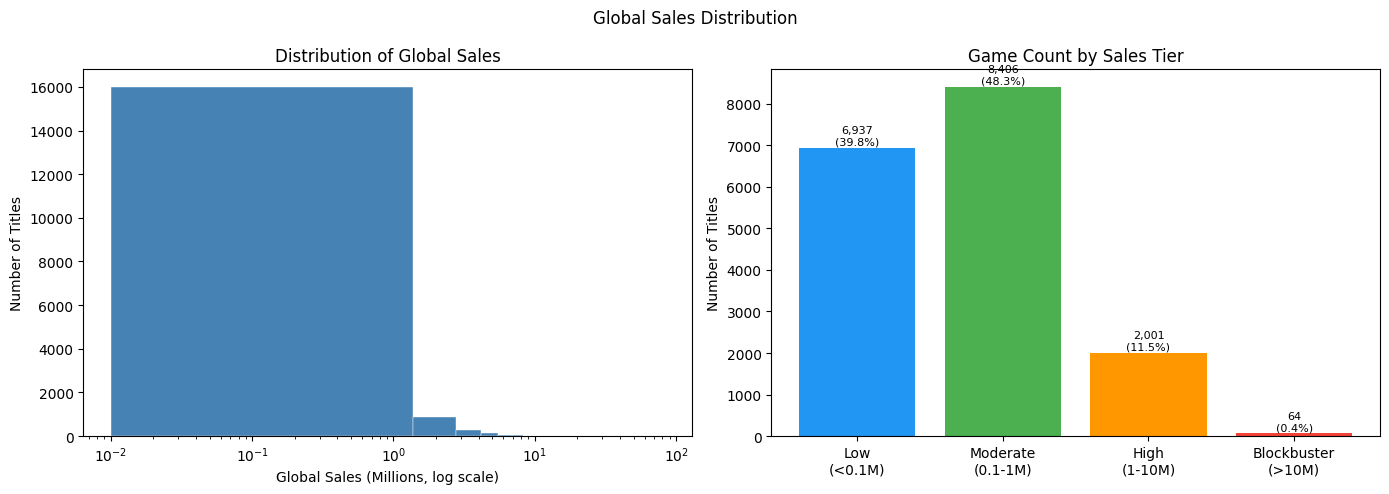

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['global_sales'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xscale('log')
axes[0].set_xlabel('Global Sales (Millions, log scale)')
axes[0].set_ylabel('Number of Titles')
axes[0].set_title('Distribution of Global Sales')

tier_keys = ['Low (<0.1M)', 'Moderate (0.1-1M)', 'High (1-10M)', 'Blockbuster (>10M)']
tier_labels = ['Low\n(<0.1M)', 'Moderate\n(0.1-1M)', 'High\n(1-10M)', 'Blockbuster\n(>10M)']
counts = df_clean['sales_tier'].value_counts().reindex(tier_keys)
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
axes[1].bar(tier_labels, counts, color=bar_colors)
axes[1].set_ylabel('Number of Titles')
axes[1].set_title('Game Count by Sales Tier')
for i, val in enumerate(counts):
    axes[1].text(i, val + 80, f'{val:,}\n({val / len(df_clean) * 100:.1f}%)', ha='center', fontsize=8)

plt.suptitle('Global Sales Distribution', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** The global sales distribution is heavily skewed to the right: the median title sells 0.16M units while the mean is 0.52M, a ratio that signals extreme concentration at the top. Nearly 88% of titles sell fewer than 1M copies, and only 64 games (0.4%) qualify as blockbusters above 10M. Despite this, the top 10 titles account for only 4.1% of total global sales and the top 100 for 16.3%, meaning the long tail of moderate sellers collectively contributes most of the market's commercial volume. For an AI development tool targeting actionable market benchmarks, the Moderate tier (0.1M to 1M) represents the typical commercial outcome for a released title.

#### Q6: How do critic scores and user scores compare?

In [32]:
reviewed = df_clean.dropna(subset=['critic_score', 'user_score']).copy()
reviewed['user_score_scaled'] = reviewed['user_score'] * 10

print(f"Records with both scores: {len(reviewed):,}")
print()
print("Critic score (0-100 scale):")
print(f"  Mean:   {reviewed['critic_score'].mean():.2f}")
print(f"  Median: {reviewed['critic_score'].median():.2f}")
print(f"  Std:    {reviewed['critic_score'].std():.2f}")
print()
print("User score (scaled to 0-100 for comparison):")
print(f"  Mean:   {reviewed['user_score_scaled'].mean():.2f}")
print(f"  Median: {reviewed['user_score_scaled'].median():.2f}")
print(f"  Std:    {reviewed['user_score_scaled'].std():.2f}")
print()

reviewed['score_gap'] = reviewed['critic_score'] - reviewed['user_score_scaled']
print(f"Mean critic-user gap: {reviewed['score_gap'].mean():.2f} points")
print(f"  Positive = critics rated higher than users")
print(f"  Negative = users rated higher than critics")
print()

print("Mean critic vs user score gap by genre:")
genre_gap = (
    reviewed.groupby('genre')['score_gap']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
print(genre_gap.to_string())

Records with both scores: 7,191

Critic score (0-100 scale):
  Mean:   70.22
  Median: 72.00
  Std:    13.88

User score (scaled to 0-100 for comparison):
  Mean:   71.74
  Median: 75.00
  Std:    14.44

Mean critic-user gap: -1.53 points
  Positive = critics rated higher than users
  Negative = users rated higher than critics

Mean critic vs user score gap by genre:
genre
Sports          2.86
Shooter         0.30
Strategy       -0.42
Misc           -0.99
Racing         -1.34
Simulation     -1.74
Puzzle         -1.79
Action         -3.11
Fighting       -3.24
Role-Playing   -3.29
Platform       -3.56
Adventure      -5.23


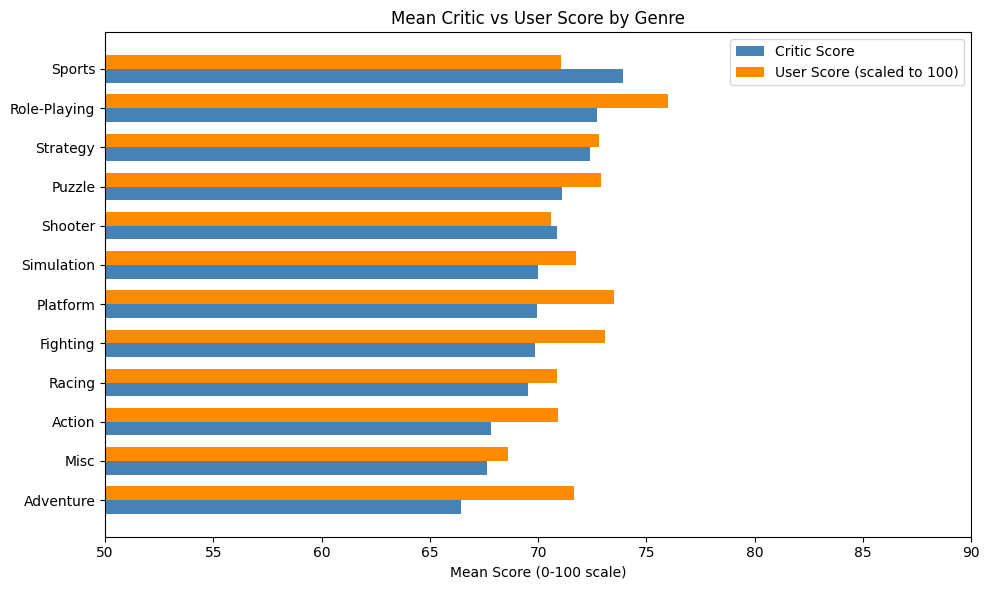

In [33]:
reviewed_scores = df_clean.dropna(subset=['critic_score', 'user_score']).copy()
reviewed_scores['user_score_scaled'] = reviewed_scores['user_score'] * 10

genre_compare = reviewed_scores.groupby('genre').agg(
    mean_critic=('critic_score', 'mean'),
    mean_user=('user_score_scaled', 'mean'),
).round(2).sort_values('mean_critic', ascending=True)

y = range(len(genre_compare))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([i - width / 2 for i in y], genre_compare['mean_critic'], width, label='Critic Score', color='steelblue')
ax.barh([i + width / 2 for i in y], genre_compare['mean_user'], width, label='User Score (scaled to 100)', color='darkorange')
ax.set_yticks(list(y))
ax.set_yticklabels(genre_compare.index)
ax.set_xlabel('Mean Score (0-100 scale)')
ax.set_title('Mean Critic vs User Score by Genre')
ax.set_xlim(50, 90)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Critics and users track closely on average: mean critic score is 70.22 versus 71.74 (scaled to 100) for users, a gap of only 1.52 points. Patterns at the genre level reveal meaningful divergences in evaluation standards. Sports and Shooter are the only genres where critics rate consistently higher than users (gaps of 2.86 and 0.30 points respectively), with Sports showing the strongest effect and possibly reflecting critic appreciation for technical execution alongside player fatigue from annual franchise releases. Adventure shows the largest gap in favor of users at 5.23 points, suggesting players assign more value to narrative experience than critics do. Role Playing and Platform show similar gaps in the 3 to 4 point range. These systematic differences by genre carry direct implications for calibrating what quality means when targeting a specific audience.

#### Q7: Do higher rated games tend to have higher global sales?

In [34]:
critic_sales_corr = reviewed['critic_score'].corr(reviewed['global_sales']).round(3)
user_sales_corr   = reviewed['user_score'].corr(reviewed['global_sales']).round(3)

print("Pearson correlation with global sales:")
print(f"  Critic score: {critic_sales_corr}")
print(f"  User score:   {user_sales_corr}")
print()
print("Note: correlation measures linear association only.")
print("Given the heavy sales skew, a low correlation does not rule out")
print("a relationship between quality and commercial success.")

Pearson correlation with global sales:
  Critic score: 0.237
  User score:   0.088

Note: correlation measures linear association only.
Given the heavy sales skew, a low correlation does not rule out
a relationship between quality and commercial success.


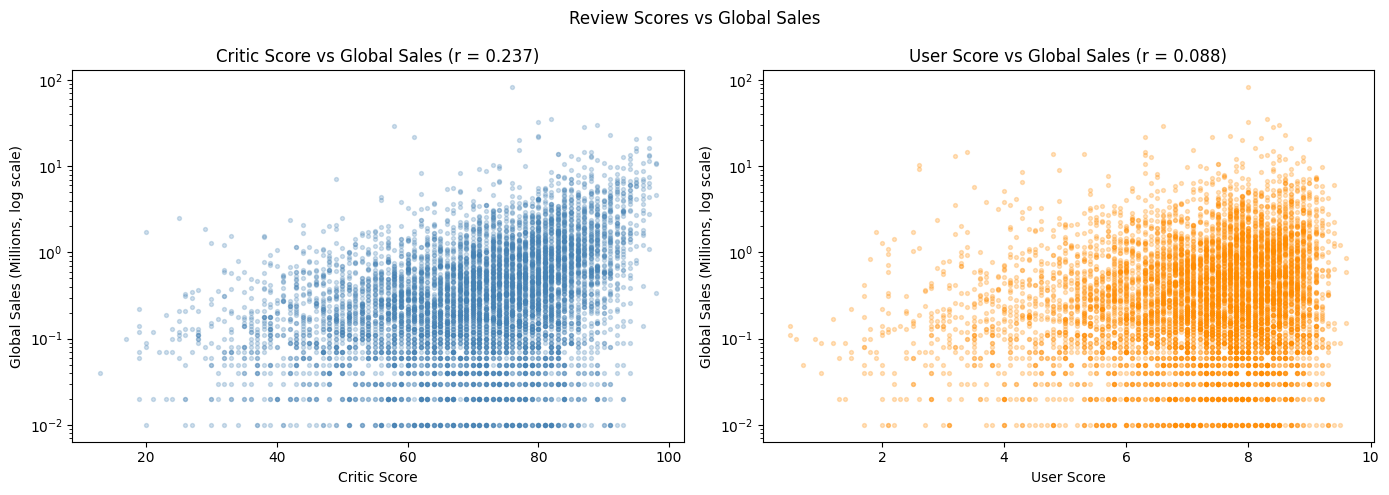

In [35]:
reviewed_scatter = df_clean.dropna(subset=['critic_score', 'user_score']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(reviewed_scatter['critic_score'], reviewed_scatter['global_sales'],
                alpha=0.25, s=8, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Global Sales (Millions, log scale)')
axes[0].set_title(f'Critic Score vs Global Sales (r = {critic_sales_corr:.3f})')

axes[1].scatter(reviewed_scatter['user_score'], reviewed_scatter['global_sales'],
                alpha=0.25, s=8, color='darkorange')
axes[1].set_yscale('log')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Global Sales (Millions, log scale)')
axes[1].set_title(f'User Score vs Global Sales (r = {user_sales_corr:.3f})')

plt.suptitle('Review Scores vs Global Sales', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:** Critic score has a modest positive correlation with global sales (r = 0.237), while user score is nearly uncorrelated (r = 0.088). The scatter plots show no clean linear relationship: many highly scored games sell modestly, and some low scoring games sell well. Commercial success is driven more by franchise strength, marketing investment, and platform installed base than by review scores alone. The stronger correlation for critic score compared to user scores may reflect that critical coverage drives consumer awareness more than pure quality perception does. For an AI game development tool, this suggests critic score is a useful but limited signal. Market positioning and genre selection likely matter more than quality ratings when predicting commercial outcomes.

The seven questions above establish the market context. Section 7 presents four standalone polished charts that distill the most significant findings for presentation and reporting.

## 7. Visualizations

The following four charts present the most significant findings from the exploratory analysis in standalone, presentation ready format. Each is saved to `outputs/figures/` for use in reports or documentation.

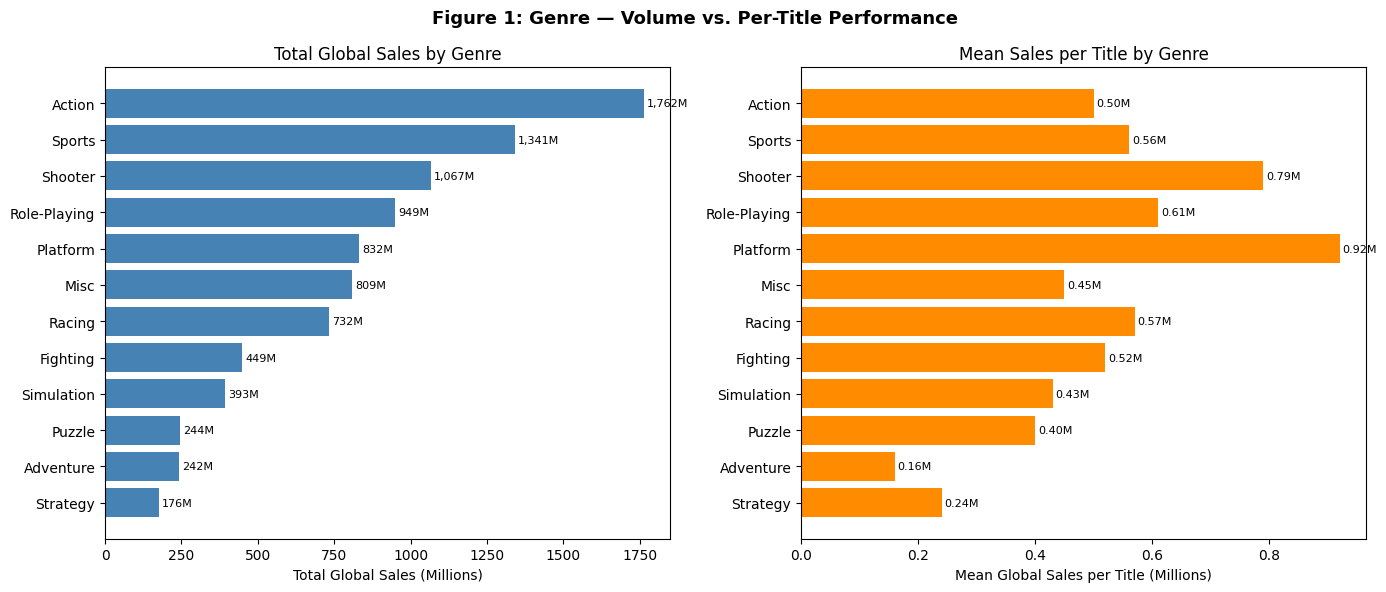

Saved: outputs/figures/fig1_genre_market_overview.png


In [36]:
import os
os.makedirs('../outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

genre_data = summaries['genre_counts'].sort_values('total_global_sales').reset_index()

bars = axes[0].barh(genre_data['genre'], genre_data['total_global_sales'], color='steelblue')
axes[0].set_xlabel('Total Global Sales (Millions)')
axes[0].set_title('Total Global Sales by Genre')
for bar, val in zip(bars, genre_data['total_global_sales']):
    axes[0].text(val + 10, bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}M', va='center', fontsize=8)

bars2 = axes[1].barh(genre_data['genre'], genre_data['mean_global_sales'], color='darkorange')
axes[1].set_xlabel('Mean Global Sales per Title (Millions)')
axes[1].set_title('Mean Sales per Title by Genre')
for bar, val in zip(bars2, genre_data['mean_global_sales']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}M', va='center', fontsize=8)

fig.suptitle('Figure 1: Genre — Volume vs. Per-Title Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig1_genre_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig1_genre_market_overview.png")

Action leads in total global sales driven by title volume, but Platform and Shooter generate higher revenue per release. This split between volume and efficiency signals that genre selection matters more commercially than raw catalog size.

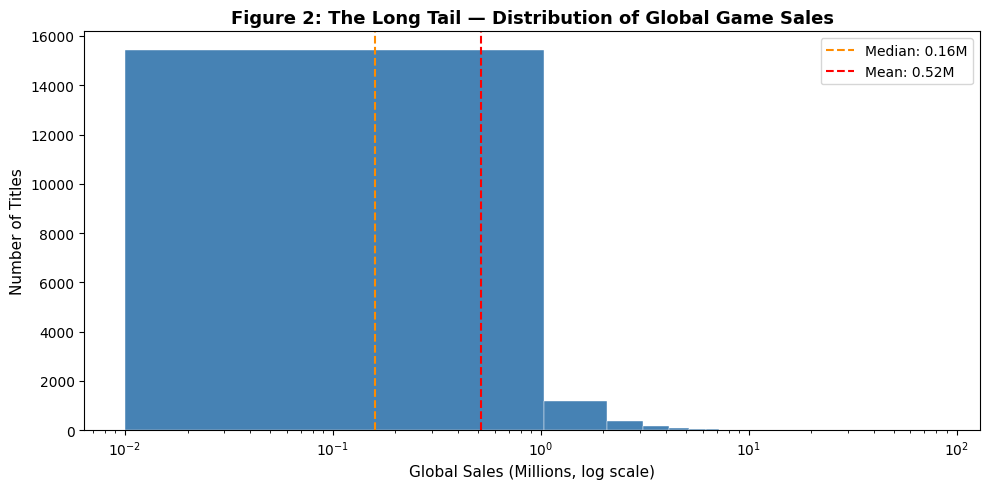

Saved: outputs/figures/fig2_sales_distribution.png


In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_clean['global_sales'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xscale('log')
ax.set_xlabel('Global Sales (Millions, log scale)', fontsize=11)
ax.set_ylabel('Number of Titles', fontsize=11)
ax.axvline(df_clean['global_sales'].median(), color='darkorange', linestyle='--', linewidth=1.5,
           label=f"Median: {df_clean['global_sales'].median():.2f}M")
ax.axvline(df_clean['global_sales'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean: {df_clean['global_sales'].mean():.2f}M")
ax.legend(fontsize=10)
ax.set_title('Figure 2: The Long Tail — Distribution of Global Game Sales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig2_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig2_sales_distribution.png")

The mean (0.52M) sits far above the median (0.16M), confirming the long tail structure characteristic of media and entertainment markets (Anderson, 2006): a small number of blockbuster titles pull the average up while the vast majority of games sell modestly. The typical commercial outcome for a released game falls in the 0.1M to 1M range.

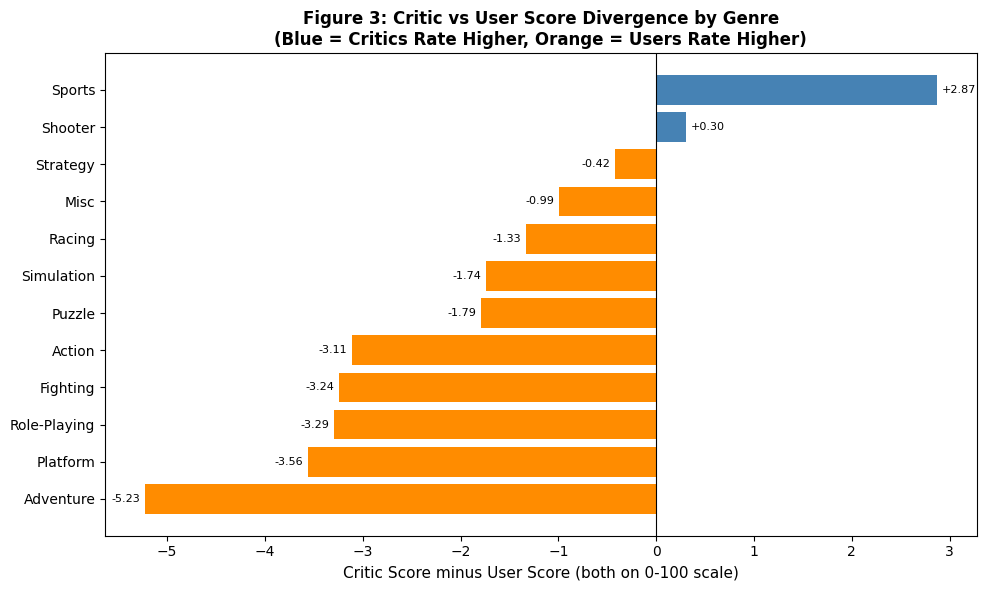

Saved: outputs/figures/fig3_score_divergence.png


In [38]:
reviewed_fig = df_clean.dropna(subset=['critic_score', 'user_score']).copy()
reviewed_fig['user_score_scaled'] = reviewed_fig['user_score'] * 10

genre_fig = reviewed_fig.groupby('genre').agg(
    mean_critic=('critic_score', 'mean'),
    mean_user=('user_score_scaled', 'mean'),
).round(2)
genre_fig['gap'] = genre_fig['mean_critic'] - genre_fig['mean_user']
genre_fig = genre_fig.sort_values('gap')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if g >= 0 else 'darkorange' for g in genre_fig['gap']]
ax.barh(genre_fig.index, genre_fig['gap'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Critic Score minus User Score (both on 0-100 scale)', fontsize=11)
for i, (genre, row) in enumerate(genre_fig.iterrows()):
    offset = 0.05 if row['gap'] >= 0 else -0.05
    ha = 'left' if row['gap'] >= 0 else 'right'
    ax.text(row['gap'] + offset, i, f"{row['gap']:+.2f}", va='center', ha=ha, fontsize=8)
ax.set_title(
    'Figure 3: Critic vs User Score Divergence by Genre\n(Blue = Critics Rate Higher, Orange = Users Rate Higher)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig3_score_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig3_score_divergence.png")

Sports and Shooter are the only genres where critics score consistently higher than users. Adventure shows the largest gap in favor of users at 5.23 points, indicating players value narrative experience more than critics do. This divergence is a useful signal for evaluating quality targets by genre.

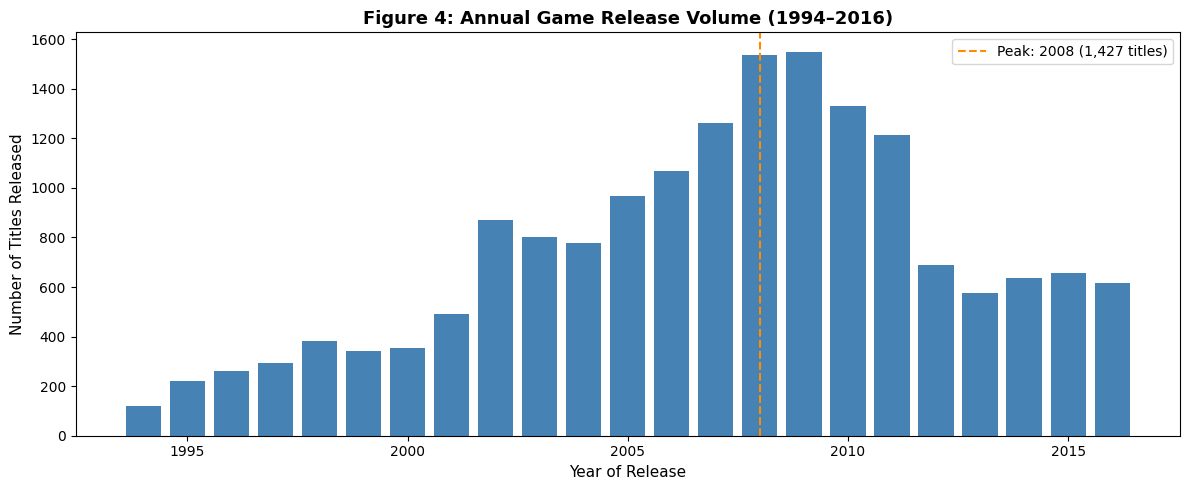

Saved: outputs/figures/fig4_release_volume.png


In [39]:
releases_fig = df_clean.groupby('year_of_release')['name'].count().reset_index()
releases_fig.columns = ['year', 'count']
releases_fig = releases_fig[(releases_fig['year'] >= 1994) & (releases_fig['year'] <= 2016)]

peak_row = releases_fig.loc[releases_fig['count'].idxmax()]
peak_year = int(peak_row['year'])
peak_count = int(peak_row['count'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(releases_fig['year'], releases_fig['count'], color='steelblue', width=0.8)
ax.set_xlabel('Year of Release', fontsize=11)
ax.set_ylabel('Number of Titles Released', fontsize=11)
ax.axvline(peak_year, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'Peak: {peak_year} ({peak_count:,} titles)')
ax.legend(fontsize=10)
ax.set_title('Figure 4: Annual Game Release Volume (1994–2016)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig4_release_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig4_release_volume.png")

Release volume peaked in 2009 and declined sharply after 2011, reflecting the industry shift toward releasing fewer titles with higher budgets and the rise of digital distribution that is largely absent from this dataset.

## 8. Responsible Data Handling and Bias Awareness

This section examines the limitations and potential biases embedded in the Video Game Sales and Ratings dataset, the assumptions made during cleaning and analysis, and the responsible use boundaries that apply to any conclusions drawn from this workflow. Recognizing these factors before interpreting findings ensures that insights are appropriately scoped and not overgeneralized.

### Era Representation and Geographic Bias

### Applying the NIST Bias Taxonomy

Rather than measuring a model's predictions, this section measures the dataset itself: which groups of games are well represented versus systematically underrepresented, and what those disparities mean for the analyses built on top of this data. The approach follows the first three steps of the Fairlearn fairness assessment workflow (harm identification, group identification, and harm quantification) applied to the data rather than to a model.

Three bias types from the NIST AI Risk Management Framework are most relevant here (National Institute of Standards and Technology, 2023).

**Historical bias** occurs when data reflects a past state that no longer accurately represents reality. This dataset captures a specific market era (primarily 2000 to 2012) and a single distribution channel (physical retail). Patterns in the data encode the commercial and cultural priorities of that era and cannot be generalized to the current market.

**Measurement bias** arises from inconsistent or incomplete data collection. Sales figures come from VGChartz, which estimates physical retail sales without direct access to publisher data. Review scores come from self-selected critics and users, producing systematic gaps tied to platform visibility and title prominence rather than objective coverage of all games.

**Aggregation bias** occurs when a single summary statistic is applied to a dataset that contains multiple distinct subpopulations. Combining games from radically different eras, platforms, and distribution channels into one analysis pool treats them as homogeneous when they are not. The coverage analysis below quantifies where this aggregation obscures meaningful group differences.

In [40]:
era_bounds = [(1980, 1999), (2000, 2005), (2006, 2010), (2011, 2016)]
era_labels = ['1980-1999', '2000-2005', '2006-2010', '2011-2016']

print("Dataset distribution by era:")
for (start, end), label in zip(era_bounds, era_labels):
    count = df_clean[
        (df_clean['year_of_release'] >= start) & (df_clean['year_of_release'] <= end)
    ].shape[0]
    pct = count / len(df_clean) * 100
    print(f"  {label}: {count:,} titles ({pct:.1f}%)")

print()

total_global = df_clean['global_sales'].sum()
regional = {
    'North America': df_clean['na_sales'].sum(),
    'Europe':        df_clean['eu_sales'].sum(),
    'Japan':         df_clean['jp_sales'].sum(),
    'Other':         df_clean['other_sales'].sum(),
}
print("Regional share of total tracked sales:")
for region, sales in regional.items():
    print(f"  {region}: {sales:,.1f}M ({sales / total_global * 100:.1f}%)")

Dataset distribution by era:
  1980-1999: 1,995 titles (11.5%)
  2000-2005: 4,262 titles (24.5%)
  2006-2010: 6,746 titles (38.8%)
  2011-2016: 4,391 titles (25.2%)

Regional share of total tracked sales:
  North America: 4,433.0M (49.3%)
  Europe: 2,450.9M (27.2%)
  Japan: 1,306.4M (14.5%)
  Other: 799.5M (8.9%)


In [41]:
coverage_by_era = []
for (start, end), label in zip(era_bounds, era_labels):
    era_slice = df_clean[
        (df_clean['year_of_release'] >= start) & (df_clean['year_of_release'] <= end)
    ]
    total = len(era_slice)
    reviewed = era_slice.dropna(subset=['critic_score', 'user_score']).shape[0]
    coverage_by_era.append({
        'era': label,
        'total_titles': total,
        'reviewed_titles': reviewed,
        'coverage_pct': round(reviewed / total * 100, 1) if total > 0 else 0,
    })

coverage_era_df = pd.DataFrame(coverage_by_era)
print("Review coverage rate by era (titles with both critic and user scores):")
print(coverage_era_df.to_string(index=False))
print()

coverage_by_genre = (
    df_clean
    .assign(has_review=df_clean[['critic_score', 'user_score']].notna().all(axis=1))
    .groupby('genre')['has_review']
    .agg(total_titles='count', reviewed_titles='sum')
    .assign(coverage_pct=lambda x: (x['reviewed_titles'] / x['total_titles'] * 100).round(1))
    .sort_values('coverage_pct')
)
print("Review coverage rate by genre:")
print(coverage_by_genre.to_string())
print()

pre_2000_cov  = coverage_era_df.loc[coverage_era_df['era'] == '1980-1999', 'coverage_pct'].iloc[0]
post_2000_cov = coverage_era_df.loc[coverage_era_df['era'] != '1980-1999', 'coverage_pct'].mean()
coverage_ratio = pre_2000_cov / post_2000_cov if post_2000_cov > 0 else 0
print(f"Pre-2000 review coverage:          {pre_2000_cov:.1f}%")
print(f"Post-2000 review coverage (avg):   {post_2000_cov:.1f}%")
print(f"Coverage ratio (pre / post):       {coverage_ratio:.3f}")
print("(1.0 = equal coverage; values near 0 indicate the pre-2000 era is systematically")
print(" underrepresented in any score-based analysis)")

Review coverage rate by era (titles with both critic and user scores):
      era  total_titles  reviewed_titles  coverage_pct
1980-1999          1995               86           4.3
2000-2005          4262             2439          57.2
2006-2010          6746             2806          41.6
2011-2016          4391             1860          42.4

Review coverage rate by genre:
              total_titles  reviewed_titles  coverage_pct
genre                                                    
Adventure             1478              279          18.9
Puzzle                 615              127          20.7
Misc                  1812              401          22.1
Simulation             924              318          34.4
Sports                2407              989          41.1
Strategy               734              304          41.4
Fighting               864              393          45.5
Platform               900              412          45.8
Racing                1281              60

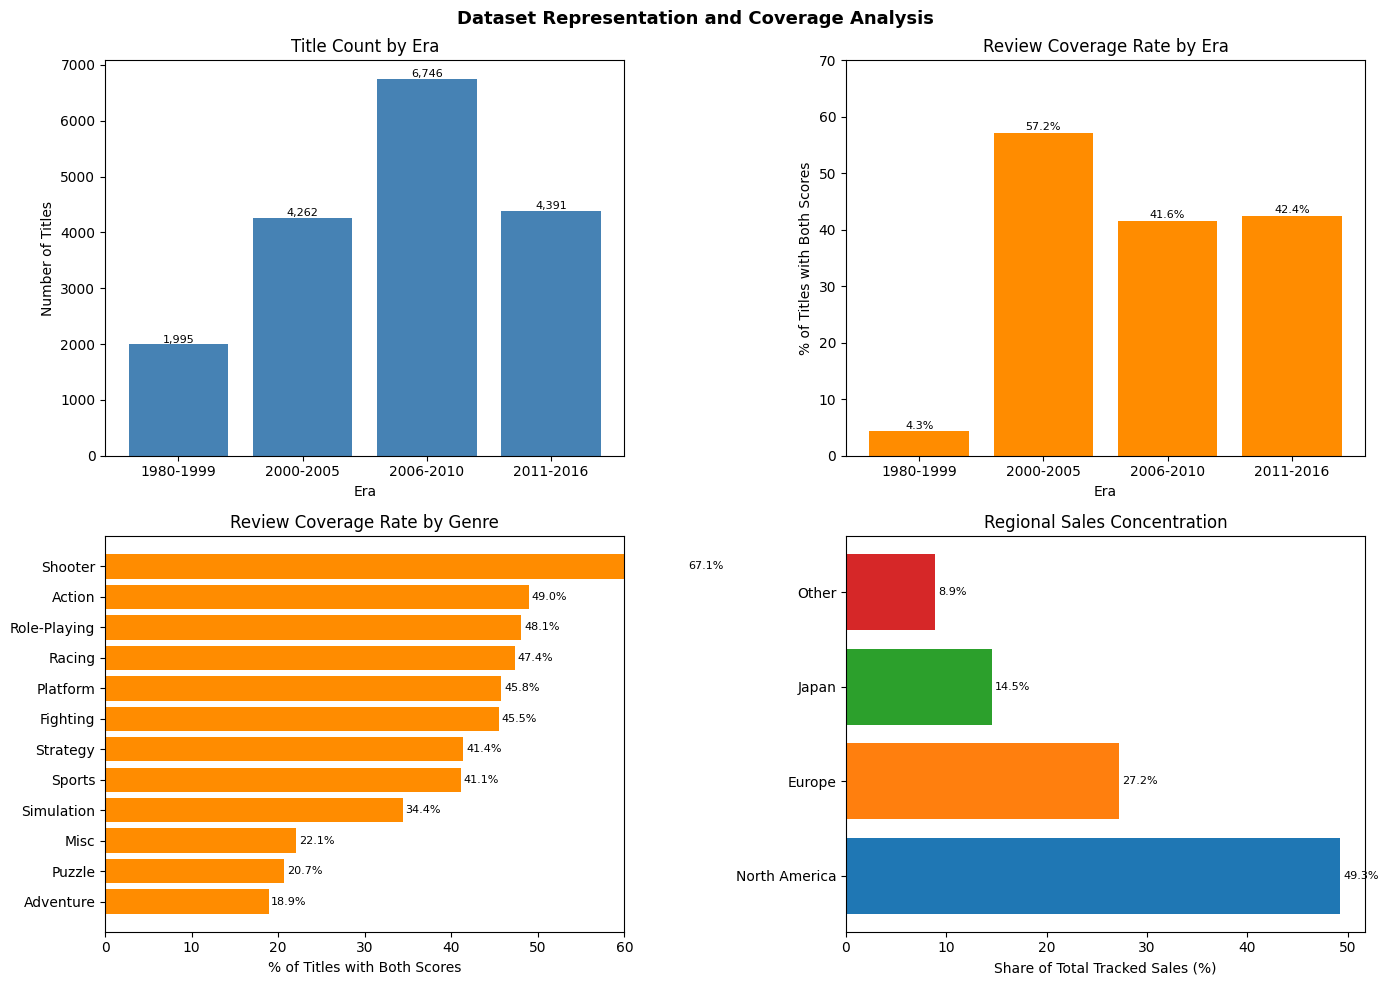

Saved: outputs/figures/fig_bias_representation.png


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Title count by era (representation analysis)
axes[0, 0].bar(coverage_era_df['era'], coverage_era_df['total_titles'], color='steelblue')
axes[0, 0].set_xlabel('Era')
axes[0, 0].set_ylabel('Number of Titles')
axes[0, 0].set_title('Title Count by Era')
for i, val in enumerate(coverage_era_df['total_titles']):
    axes[0, 0].text(i, val + 30, f'{val:,}', ha='center', fontsize=8)

# Panel 2: Review coverage rate by era (measurement bias quantification)
axes[0, 1].bar(coverage_era_df['era'], coverage_era_df['coverage_pct'], color='darkorange')
axes[0, 1].set_xlabel('Era')
axes[0, 1].set_ylabel('% of Titles with Both Scores')
axes[0, 1].set_title('Review Coverage Rate by Era')
axes[0, 1].set_ylim(0, 70)
for i, val in enumerate(coverage_era_df['coverage_pct']):
    axes[0, 1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=8)

# Panel 3: Review coverage rate by genre (aggregation bias quantification)
genre_cov = coverage_by_genre.reset_index().sort_values('coverage_pct')
axes[1, 0].barh(genre_cov['genre'], genre_cov['coverage_pct'], color='darkorange')
axes[1, 0].set_xlabel('% of Titles with Both Scores')
axes[1, 0].set_title('Review Coverage Rate by Genre')
axes[1, 0].set_xlim(0, 75)
for i, val in enumerate(genre_cov['coverage_pct']):
    axes[1, 0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)

# Panel 4: Regional sales concentration (aggregation bias quantification)
region_labels_list = list(regional.keys())
region_pcts = [v / total_global * 100 for v in regional.values()]
bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = axes[1, 1].barh(region_labels_list, region_pcts, color=bar_colors)
axes[1, 1].set_xlabel('Share of Total Tracked Sales (%)')
axes[1, 1].set_title('Regional Sales Concentration')
for bar, pct in zip(bars, region_pcts):
    axes[1, 1].text(pct + 0.3, bar.get_y() + bar.get_height() / 2,
                    f'{pct:.1f}%', va='center', fontsize=8)

fig.suptitle('Dataset Representation and Coverage Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig_bias_representation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/fig_bias_representation.png")

The era distribution reveals the most significant instance of **historical bias** in this dataset. The 2006 to 2010 window accounts for roughly 39% of all titles, while coverage before 2000 is minimal. This concentration reflects the era in which mainstream game journalism and physical retail distribution operated at their peak. Patterns identified in this analysis describe the disc based console era most accurately and should not be generalized to earlier or more recent market conditions.

The geographic breakdown is the clearest case of **aggregation bias**: North America and Europe together account for roughly 76% of all tracked sales, while Japan accounts for roughly 15% and all other markets make up the remainder. Combining these regions into a single global analysis treats a dataset dominated by Western sales as representative of global preferences. Large markets in South Korea, China, Southeast Asia, and mobile first regions are effectively absent. Genre and platform preferences observed here are best understood as Western market preferences during the disc based era.

### Review Data Bias and Measurement Gaps

The coverage analysis above quantifies a compound **measurement bias** driven by two distinct mechanisms. First, older titles were released before structured game review coverage existed at scale, making their absence from score analysis a function of when reviews became systematically available rather than a deficiency in the games themselves. Second, smaller releases, handheld titles, and certain genre categories received less critical attention regardless of era, producing a coverage gap that excludes them from any score based analysis.

The coverage ratio between the pre-2000 and post-2000 populations quantifies the scale of this disparity. When a group's coverage rate approaches zero, any score based insight drawn from the full dataset is actually drawn from the post-2000, major platform, high visibility subset only. This is a form of the **aggregation bias** identified above: treating the reviewed subset as representative of all games produces conclusions that reflect publishing conditions and review infrastructure, not market  wide patterns.

Genre level coverage rates compound this further. Adventure (below 25% coverage) and Misc (below 30% coverage) genres are particularly affected, meaning their score profiles reflect a small and prominent subset of titles within those genres. The reviewed population carries a second layer of self selection: user scores depend on consumers actively choosing to submit a review, which skews toward players with strong opinions and toward titles with large, engaged audiences. User score distributions are not a neutral sample of player satisfaction.

### Survivorship Bias and the Digital Distribution Gap

NES (2.56M) and G (2.61M) show the highest mean sales per game in the dataset, where G represents the Game Boy. This does not mean early platform games were more commercially successful on average. It reflects survivorship bias: only titles that sold well enough to be tracked by VGChartz appear in this dataset at all. The full catalog for those platforms was vastly larger than what is represented here.

The digital distribution gap is a more fundamental limitation. Mobile games, Steam releases, digital only titles, and the vast majority of indie games from the past decade are absent from this dataset. The decline in release counts visible after 2012 is an artifact of this gap rather than a real market contraction. The games industry has grown substantially since 2012, but that growth is not captured here. Any analysis of genre trends, platform performance, or market size that relies on this dataset should acknowledge that it describes a specific distribution channel during a specific window of time.

### Responsible Use Boundaries

The Pearson correlation between critic score and global sales is 0.237. This measures linear association, not causation. A game receiving strong reviews does not cause higher sales. Both variables are likely driven by common factors such as publisher investment, franchise recognition, and platform installed base. Any conclusion drawn from this correlation should be treated as historical market observation rather than a predictive or causal claim.

More broadly, this dataset should not be used to forecast modern game commercial success, identify optimal genre strategies for new releases, or draw conclusions about current market conditions. It describes the disc based console era with reasonable coverage of major Western markets. Used within those boundaries, it provides a solid foundation for historical market analysis and for establishing the context that motivates data driven approaches to game development. Conclusions should be scoped accordingly: the patterns observed here describe what the market looked like between roughly 2000 and 2012, not what it looks like today.

## 9. Summary and Interpretation

This section synthesizes the findings from Sections 6 and 7 in direct answer to the core question: what patterns in video game genre, platform, sales, and ratings data can inform the design focus of an AI-assisted game development tool? The conclusions below are grounded in the data but bounded by the limitations identified in Section 8. Patterns describe the disc-based console market of roughly 2000 to 2012, primarily as experienced in North America and Europe. They inform historical context and design reasoning, not current market forecasting.

### Key Findings

**Market structure.** Action is the most represented genre by title count (3,500 games), but volume does not predict commercial efficiency. Platform games average 0.92M in global sales per title, the highest of any genre, followed by Shooter at 0.79M. Adventure generates the lowest average at 0.16M per title despite 1,478 titles, indicating that genre selection shapes expected commercial performance more than catalog scale. DS and PS2 dominate by title count at 2,249 and 2,206 titles respectively, reflecting long commercial lifespans and broad third party support. Among modern platforms, PS4 and X360 show the strongest per-title yield at 0.80M and 0.75M respectively.

**Sales distribution.** The market follows a long tail structure. The median title sells 0.16M units while the mean is 0.52M, a gap driven by a small number of blockbusters at the high end. Only 64 titles (0.4%) exceed 10M units. The realistic commercial benchmark for a released title is the Moderate tier (0.1M to 1M), which contains 48.3% of all games. The top 100 titles account for only 16.3% of total global sales, confirming that the long tail contributes substantially to aggregate market volume.

**Score patterns.** Critics and users evaluate games similarly on average (mean scores of 70.22 and 71.74 on a 100-point scale), but genre-level divergences are meaningful. Sports and Shooter are the only genres where critics rate higher than users, with Sports showing the largest gap at 2.86 points. Adventure shows the largest gap in favor of users at 5.23 points, suggesting players assign more value to narrative experience than critics do. Critic score has a modest positive correlation with global sales (r = 0.237), while user score is nearly uncorrelated (r = 0.088). Review scores are a limited predictor of commercial success.

**Temporal context.** Physical retail release volume peaked in 2009 and declined sharply after 2011. Action dominated release volume from 2005 onward. The post-2012 decline in this dataset is an artifact of the digital distribution gap, not a real market contraction.

### Implications for AI-Assisted Game Development

The patterns above suggest several design principles for AI-assisted game development tooling.

**Genre selection is a primary commercial variable.** The data shows clearly that genre shapes expected revenue per release more than most other observable factors. A tool that ignores genre positioning would be missing the most actionable signal in this dataset.

**Quality calibration should be genre-aware.** Critics and players evaluate genres by different standards. A uniform quality target applied across genres would misrepresent what good means to the relevant audience. This is particularly true for Adventure and Role-Playing titles, where users consistently rate higher than critics.

**The Moderate sales tier is the realistic benchmark.** Calibrating AI tools against blockbuster outcomes above 10M units would be appropriate for 0.4% of the market. For most development decisions, the 0.1M to 1M range represents the realistic reference point.

**Review scores are context, not targets.** The weak relationship between review scores and commercial outcomes confirms that scores should inform quality awareness, not serve as a primary optimization target. Franchise positioning, platform selection, and marketing are likely more influential factors.

This analysis provides market context that motivates data-driven approaches to game development. It does not directly drive model training or system design, but it establishes the genre, platform, and quality landscape that future AI tools in this space would need to navigate.

### Assumptions and Limitations

**Sales data accuracy.** The analysis assumes VGChartz estimates are directionally accurate even if not precisely verified against publisher data. Relative patterns are likely more reliable than absolute figures. Conclusions that depend on precise sales counts rather than rank or relative magnitude should be treated with caution.

**Reviewed subset representativeness.** Score analyses are based on the roughly 41% of titles that have both critic and user scores. This subset skews toward post-2000, major-platform, high-visibility releases. Score findings do not generalize to the full dataset and should not be treated as representative of all games in all eras.

**Linearity assumption.** The Pearson correlations assume a linear relationship between scores and sales. Given the heavily skewed sales distribution, a nonlinear relationship may exist, particularly in the blockbuster tier. The correlation values should be read as a lower bound on the relationship strength rather than a definitive measure.

**Western market scope.** The global sales figures are dominated by North America and Europe, which together account for roughly 76% of tracked sales. Any conclusion framed as a global market insight is more accurately a Western market insight from the disc-based console era. Japanese preferences and all other regional markets, which are largely absent from this data, may differ substantially.

## 10. Future Integration

This analysis was designed as a market context layer, not a model training pipeline. 
Even so, it surfaces data patterns and workflow decisions that directly inform how AI tools 
could be applied to game development research, recommendation, and design assistance. 
Three integration pathways are worth considering: supervised machine learning, deep learning, 
and agentic automation.


### How This Workflow Could Support Machine Learning

The cleaned dataset produced here is well suited as a feature table for supervised learning experiments. 
Genre, platform, publisher, release year, and ESRB rating are all categorical features that could be 
one-hot encoded with minimal preprocessing. Global sales and critic score could serve as regression targets 
for commercial viability or quality prediction models. The groupby summaries from `summarize_game_market` 
already reveal which features carry signal: genre is the strongest structural predictor of both volume and 
revenue distribution, and critic score shows a modest but nonzero correlation with sales. A next step would 
be to split the dataset by era, train separate models on pre-2000 and post-2000 titles, and compare 
feature importance across periods to test whether the drivers of commercial success shifted over time.

The modular src/ structure used here also transfers cleanly to an ML pipeline. The cleaning functions would 
run as preprocessing steps before feature engineering, and the EDA summaries would feed a validation stage 
that checks for distribution shift between training and scoring data.


### How the Dataset Would Need to Change for Neural Networks

Neural networks are generally a poor fit for tabular data at this scale and would require substantial 
dataset changes before they add value over tree based models. Research has shown that tree based 
models consistently outperform deep learning on structured tabular datasets (Grinsztajn et al., 2022). The current dataset has roughly 17,000 rows 
after cleaning, which is small for deep learning. A neural approach would require augmentation with 
additional data sources: user review text from Metacritic or Steam, game cover art, genre tag graphs, or 
gameplay feature embeddings extracted from descriptions. With that richer input, recurrent or transformer 
architectures could learn latent genre representations that go beyond the 12 discrete genre labels in the 
current data (Vaswani et al., 2017).

The coverage bias identified in Section 8 would become a more serious problem in a neural setting. 
Pre-2000 titles make up a meaningful share of total game history but carry almost no review data, so 
a neural model trained on this dataset would have almost no signal for that era. Addressing that gap 
would require either a targeted data collection effort for classic titles or explicit era conditioning 
so the model learns to treat coverage sparse eras as a distinct input regime rather than noise.


### How Agentic Automation Could Assist This Workflow

The workflow built here is reproducible but still manual: a human decides which questions to ask, which 
thresholds to apply in cleaning, and which charts to generate. An agentic system could automate several 
of those decision points. A planning agent could inspect a new dataset, identify column types and missing 
value patterns, propose a cleaning strategy, and execute it without step by step human direction. A 
second agent could generate candidate visualizations, score them against a legibility rubric, and surface 
only the most informative ones for human review.

For ongoing market monitoring, an agentic pipeline could ingest new sales or review data on a schedule, 
rerun the EDA summaries, compare them to a stored baseline, and flag statistically significant shifts 
in genre distribution or score gaps. That kind of automated drift detection would free analysts to focus 
on interpretation rather than repeated execution. The modular function design in this project, with 
cleaning, inspection, and EDA separated into distinct callable units, is already structured in a way 
that would make it straightforward to wrap each stage as an agent tool.
